![Machine Learning for Loan Approval](wide_clean_modern_tech_themed_banner_hero_image.png)


# **1.0 Title**
# Machine Learning for Loan Approval and Risk Assessment

>FinTech Innovations — Data-Driven Credit Risk Analysis


## Overview

### Bottom Line Up Front (BLUF)

This project aims to help FinTech Innovations make loan approval decisions faster, more consistently, and with less financial risk. By using information from past loan applications and their repayment outcomes, we will develop a machine learning model that can identify applicants who are more likely to repay their loans and those who may present a higher risk of default.

The final model will be evaluated not only on how accurately it makes predictions, but also on what those predictions could mean financially for the business. This is important because the cost of approving a loan that later defaults is much higher than the cost of mistakenly denying a loan to a creditworthy applicant. The final results will therefore show how well the model performs, how its mistakes could affect the business financially, and how it could support loan officers in making better-informed decisions.

### The Story

FinTech Innovations currently depends heavily on manual loan reviews. While loan officers play an important role in assessing applicants, manual decisions can take time and may not always be consistent. This project explores whether historical loan data can be used to provide a more consistent and evidence-based approach to loan assessment. We will first understand the data and identify important patterns, then prepare the information for analysis, build and compare several prediction models, and finally select and evaluate a suitable model. The goal is not simply to create a model that makes predictions, but to develop a solution that makes sense from a business perspective and can provide useful information to loan officers and management.


# **2.0 Business Understanding**

### 2.01 Business Context

> FinTech Innovations currently relies heavily on manual review when deciding whether to approve loan applications. Loan officers examine information provided by applicants and use their judgment to decide whether an applicant is likely to repay the loan.
>
> Although this process allows human judgment to be considered, it can be time-consuming and may result in inconsistent decisions between applicants. A data-driven approach could help make the process more consistent, faster, and more evidence-based.
>
> The main business challenge is to identify applicants who are likely to repay their loans while reducing the number of loans approved to applicants who eventually default. At the same time, the company needs to avoid unnecessarily rejecting applicants who are capable of repaying their loans.

### 2.02 Key Stakeholders and Their Needs

> **Loan officers:** Need a reliable tool that can support their decisions and help them assess applications consistently.
>
> **Management:** Needs a process that reduces financial losses while improving the efficiency of loan decisions.
>
> **Customers:** Need a fair and reasonably quick application process that does not unnecessarily reject creditworthy applicants.
>
> **Risk and compliance teams:** Need decisions that can be explained and reviewed because lending decisions can have significant financial and regulatory consequences.
>
> **FinTech Innovations:** Needs to balance growth in lending with the risk of approving loans that may not be repaid.

### 2.03 Business Impact of Model Errors

> Not all mistakes made by a loan decision system have the same financial consequences.
>
> A **false approval** occurs when the model recommends approving an applicant who eventually defaults. According to the business case, each such mistake has an average cost of **$50,000**, including the loan principal and collection costs.
>
> A **false denial** occurs when the model rejects an applicant who would have successfully repaid the loan. The estimated cost of this mistake is an average of **$8,000 in lost profit**.
>
> This means that the business needs to pay particular attention to applicants who may default. However, the model should not simply reject as many applicants as possible, because doing so could result in substantial lost business and prevent creditworthy customers from receiving loans.
>
> The objective is therefore to find a practical balance between reducing costly bad-loan approvals and avoiding unnecessary rejection of good applicants.

### 2.04 Choice of Modeling Approach

> For this project, I will use a **classification approach**, with `LoanApproved` as the target variable.
>
> Classification is appropriate because the business has a direct decision to make: whether a loan application should be approved or not. The dataset contains a `LoanApproved` outcome from historical applications, allowing the model to learn patterns associated with previous approval decisions.
>
> A classification model also makes it possible to clearly identify different types of decision errors. This makes the model's performance easier to connect to the financial costs described by the business.
>
> The `RiskScore` variable will be examined during the data-understanding stage before being considered as a possible predictor. If it was generated using information that would only be available after the lending decision, using it could give the model information that would not be available when making a real application decision. We will therefore investigate it before deciding whether it can safely be used.

### 2.05 Modeling Goals

> The main goal is to develop a model that can support FinTech Innovations in making more consistent and informed loan approval decisions.
>
> The specific goals are to:
>
> 1. Identify patterns in historical loan applications associated with loan approval outcomes.
> 2. Develop a model that can distinguish between applicants who should be approved and those who represent higher risk.
> 3. Reduce costly approvals of loans that eventually default.
> 4. Avoid unnecessarily rejecting applicants who are likely to repay.
> 5. Create a model that performs consistently on applications it has not previously seen.
> 6. Provide results that loan officers and management can understand and use.

### 2.06 Success Criteria and Evaluation Metrics

> Model performance will be evaluated using several measures rather than relying on accuracy alone. This is important because the financial consequences of the two types of mistakes are very different.
>
> **Recall:** Recall will help us measure how effectively the model identifies applicants belonging to the risk category we are trying to detect. A higher recall means the model is identifying more of the applicants who could represent a potential risk.
>
> **Precision:** Precision will help us understand how often applicants identified as risky actually belong to the risky group. This is important because incorrectly identifying too many applicants as risky could result in creditworthy customers being unnecessarily rejected.
>
> **ROC-AUC:** ROC-AUC will provide an overall measure of how well the model separates the two groups across different decision thresholds. This will help us understand whether the model can meaningfully distinguish between different levels of loan risk.
>
> **Business Cost Metric:** In addition to standard machine-learning measures, we will create a business-focused cost measure based on the financial consequences provided by FinTech Innovations:
>
> * False approval/default: **$50,000 loss**
> * False denial/good applicant: **$8,000 lost profit**
>
> This will allow us to translate model errors into estimated financial consequences.

### 2.07 Baseline Performance

> Before evaluating more advanced models, we will establish a simple baseline. The baseline will provide a reference point for determining whether our machine-learning models are actually providing useful improvement.
>
> The baseline will be evaluated using the same relevant metrics used for the trained models. Each candidate model will then be compared against this baseline.
>
> The final model will be considered successful if it provides meaningful improvement over the baseline while maintaining a reasonable balance between identifying risky applications and avoiding unnecessary rejection of creditworthy applicants.


## **3.0 Data Understanding**


In [33]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# EDA Code Here - Create New Cells As Needed
None

In [35]:
# Load the dataset

df = pd.read_csv("financial_loan_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [36]:
# Dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [37]:
# Dataset dimensions and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 20000
Number of columns: 35

Column names:
['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


In [38]:
# Classify variables

numerical_features = [
    'Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
    'NumberOfDependents', 'MonthlyDebtPayments',
    'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries', 'DebtToIncomeRatio',
    'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
    'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
    'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
    'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'
]

categorical_features = [
    'EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
    'BankruptcyHistory', 'LoanPurpose'
]

ordinal_features = ['EducationLevel']

target = 'LoanApproved'

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Ordinal features:", len(ordinal_features))
print("Target:", target)

Numerical features: 27
Categorical features: 5
Ordinal features: 1
Target: LoanApproved


In [39]:
# Missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Features with missing values:")
display(missing_values)

Features with missing values:


MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

In [40]:
# Missing-value percentages

missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_percentage = missing_percentage[missing_percentage > 0]

display(missing_percentage)

MaritalStatus            6.655
EducationLevel           4.505
SavingsAccountBalance    2.860
dtype: float64

In [41]:
# Duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [42]:
# Loan approval distribution

approval_counts = df['LoanApproved'].value_counts().sort_index()

print("Loan approval counts:")
display(approval_counts)

print("\nLoan approval percentages:")
display(df['LoanApproved'].value_counts(normalize=True).sort_index() * 100)

Loan approval counts:


0    15220
1     4780
Name: LoanApproved, dtype: int64


Loan approval percentages:


0    76.1
1    23.9
Name: LoanApproved, dtype: float64

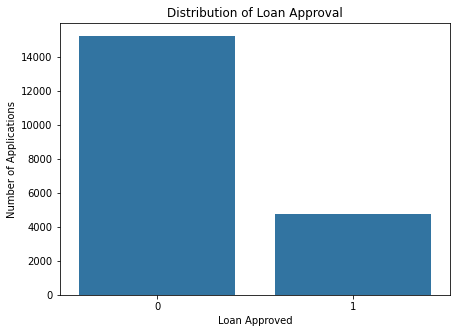

In [43]:
# Loan approval distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='LoanApproved')

plt.title('Distribution of Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Number of Applications')

plt.show()

In [44]:
# Summary statistics for numerical features

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


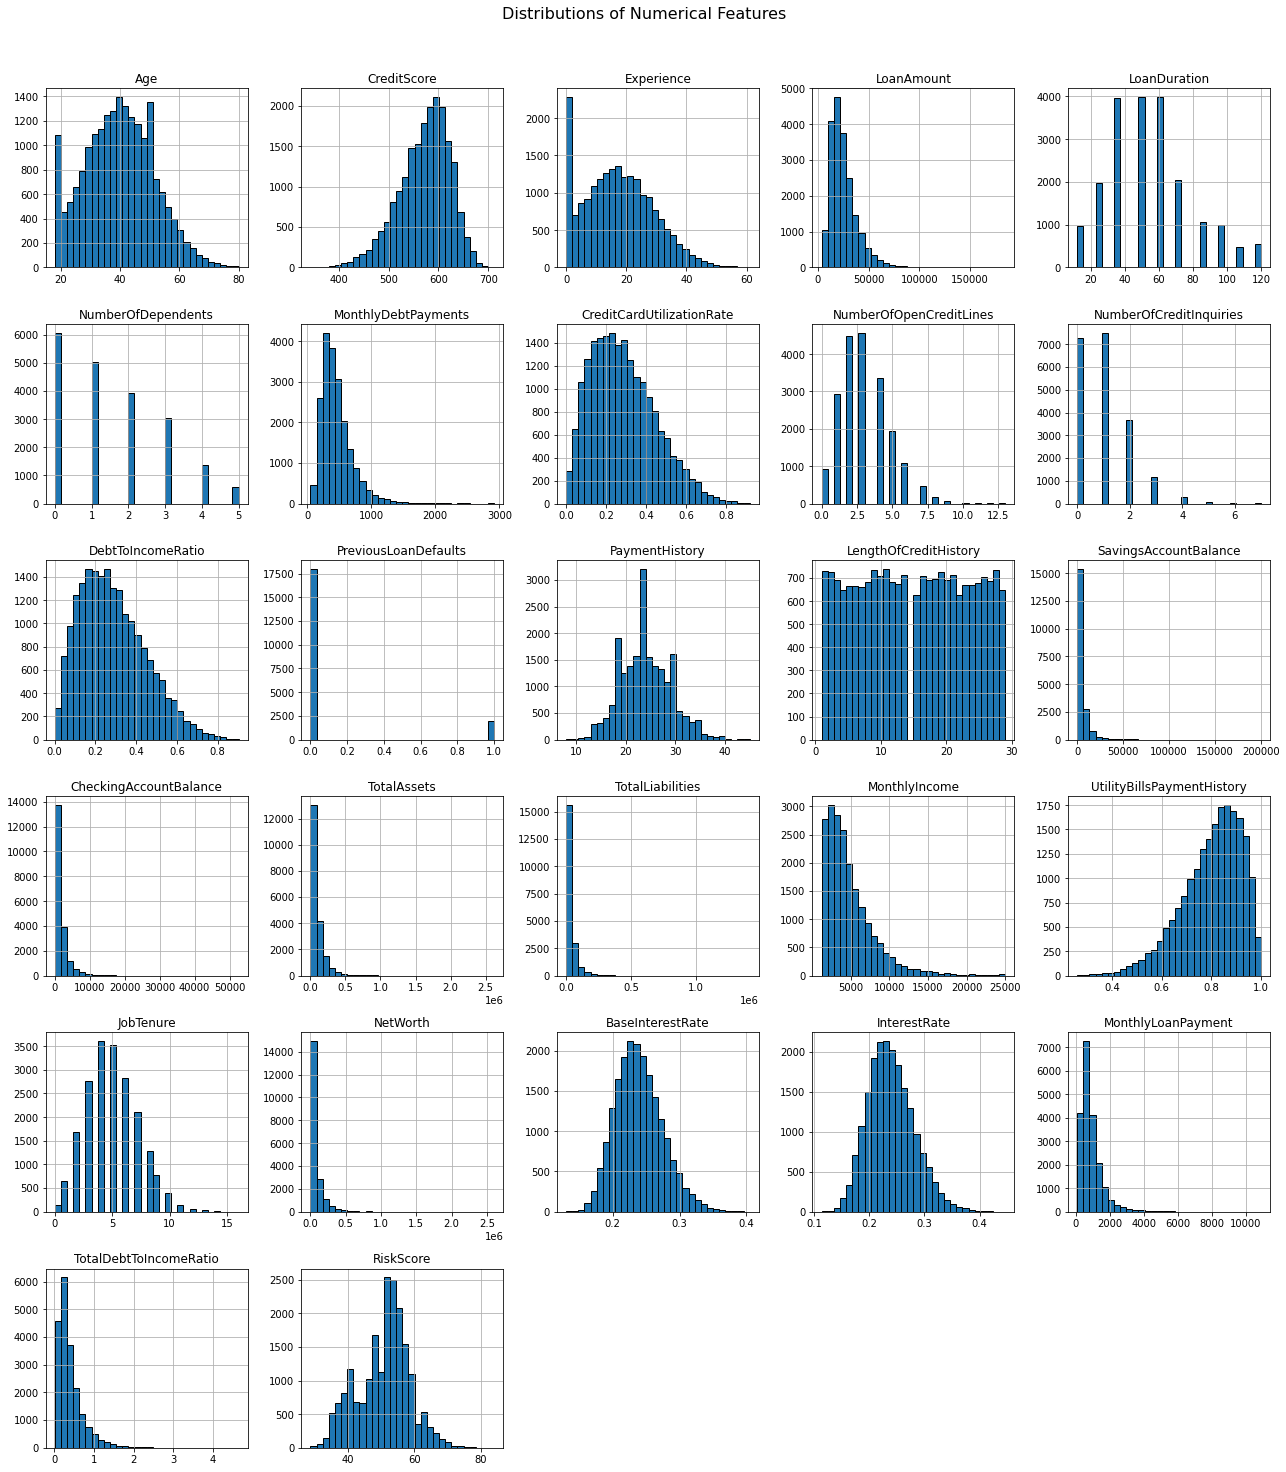

In [45]:
# Distribution of numerical features

df[numerical_features].hist(
    figsize=(18, 20),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    'Distributions of Numerical Features',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

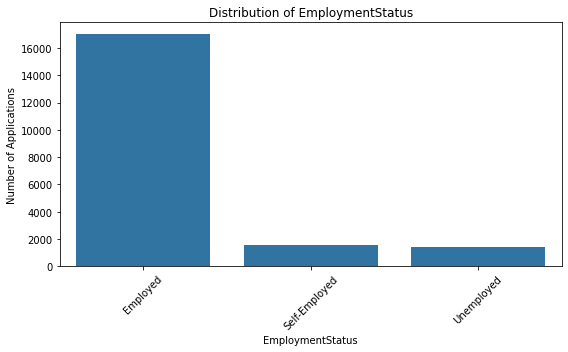

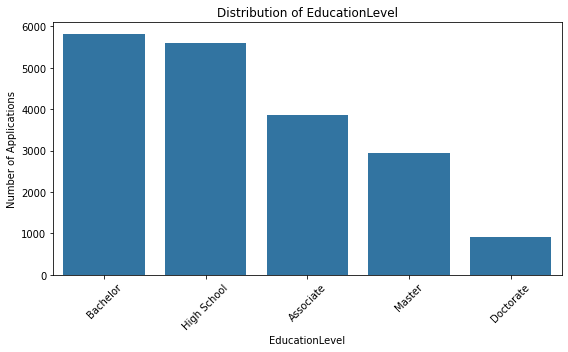

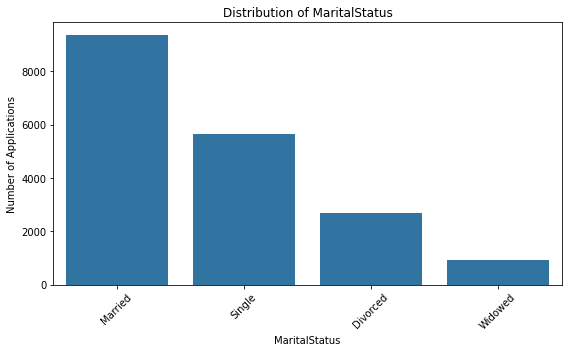

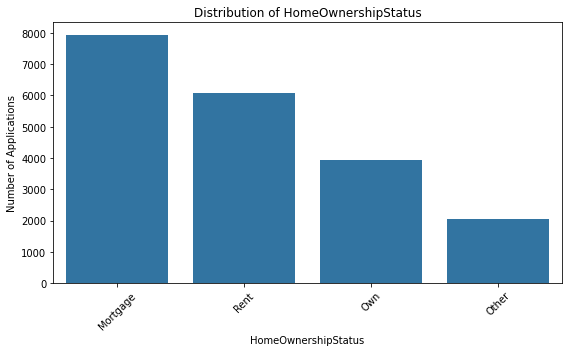

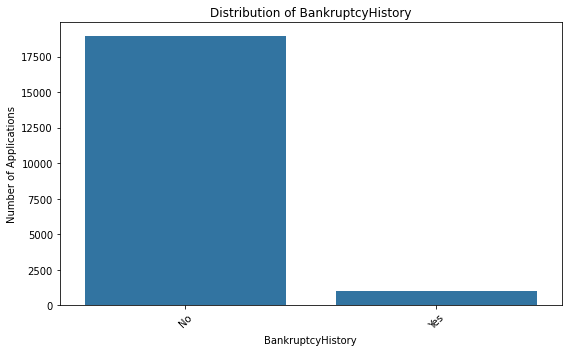

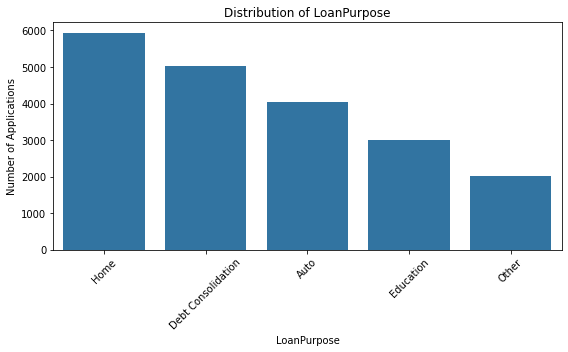

In [46]:
# Distribution of categorical and ordinal features

categorical_ordinal_features = [
    'EmploymentStatus',
    'EducationLevel',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'BankruptcyHistory',
    'LoanPurpose'
]

for feature in categorical_ordinal_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Applications')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

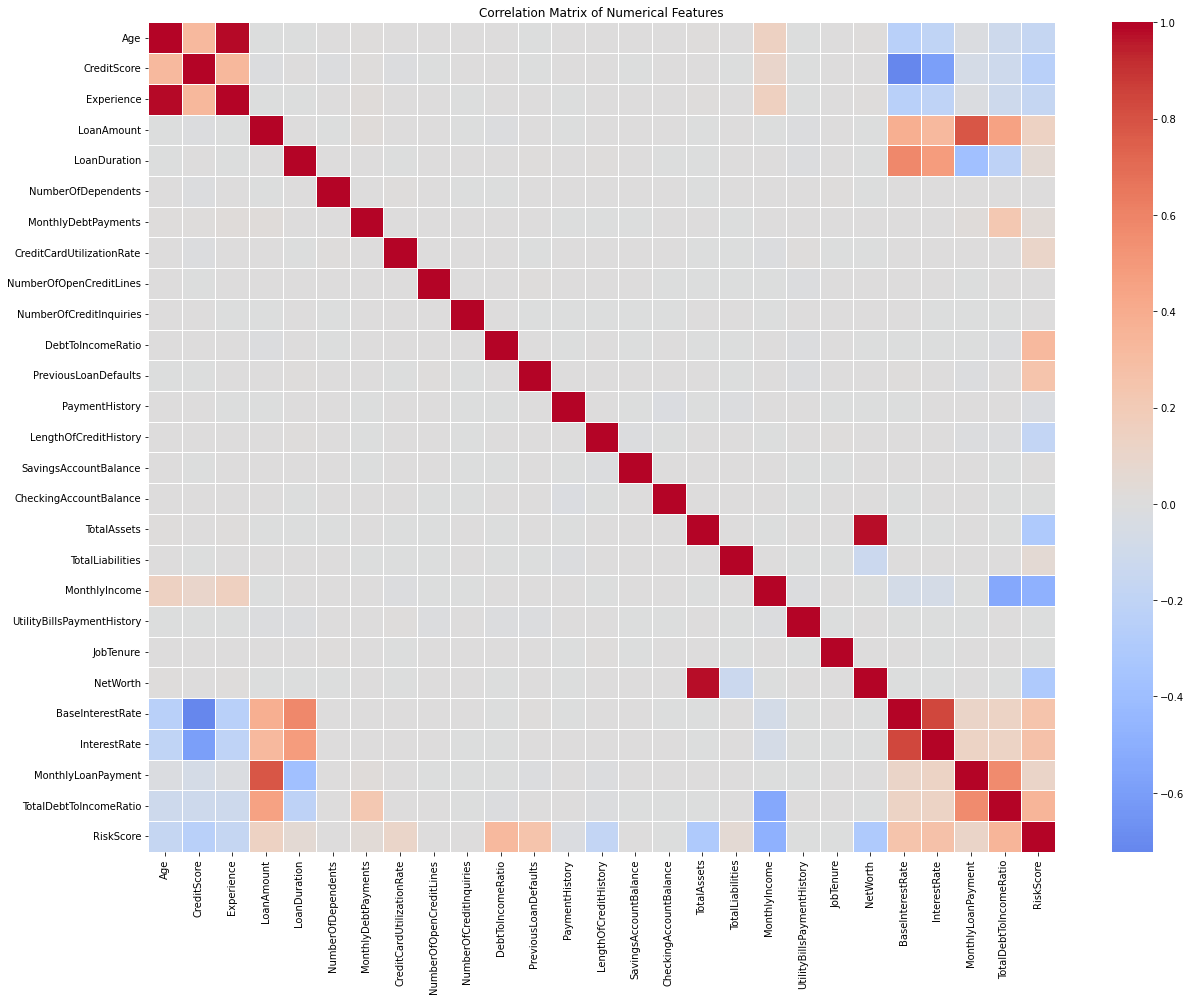

In [47]:
# Correlation matrix for numerical features

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [48]:
# Find the strongest numerical correlations

correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

display(correlation_pairs.head(15))

Age                     Experience                0.982980
TotalAssets             NetWorth                  0.978997
BaseInterestRate        InterestRate              0.834557
LoanAmount              MonthlyLoanPayment        0.780828
CreditScore             BaseInterestRate         -0.722619
                        InterestRate             -0.598844
LoanDuration            BaseInterestRate          0.579215
MonthlyLoanPayment      TotalDebtToIncomeRatio    0.567842
MonthlyIncome           TotalDebtToIncomeRatio   -0.538314
LoanDuration            InterestRate              0.487994
MonthlyIncome           RiskScore                -0.487039
LoanAmount              TotalDebtToIncomeRatio    0.457175
                        BaseInterestRate          0.385663
LoanDuration            MonthlyLoanPayment       -0.385495
TotalDebtToIncomeRatio  RiskScore                 0.342643
dtype: float64

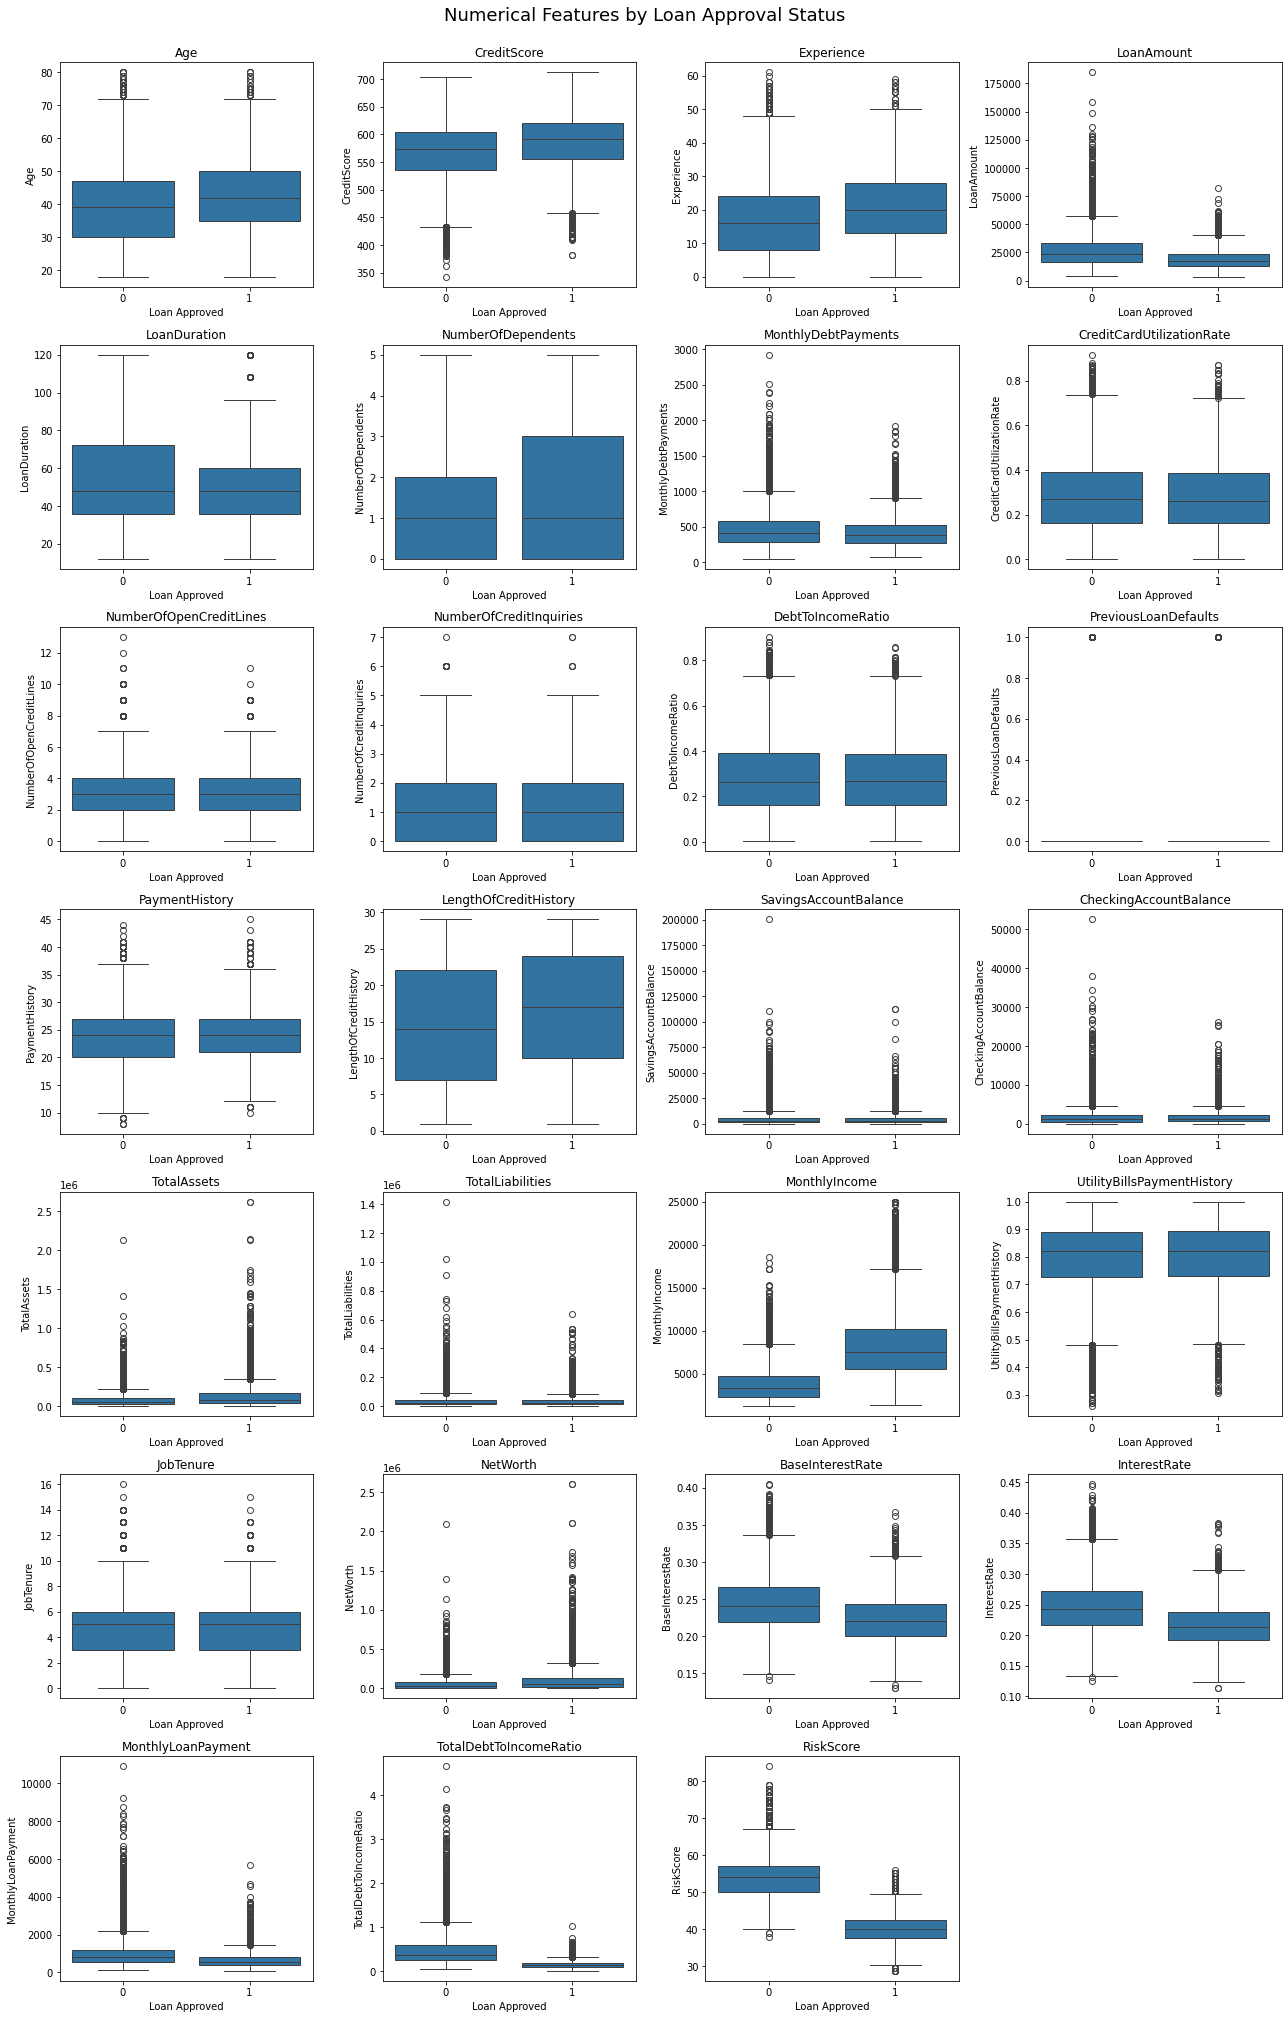

In [49]:
# Compare all numerical features by loan approval status

fig, axes = plt.subplots(7, 4, figsize=(18, 28))

axes = axes.flatten()

for ax, feature in zip(axes, numerical_features):
    
    sns.boxplot(
        data=df,
        x='LoanApproved',
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature)
    ax.set_xlabel('Loan Approved')
    ax.set_ylabel(feature)

# Hide unused subplot
for ax in axes[len(numerical_features):]:
    ax.set_visible(False)

plt.suptitle(
    'Numerical Features by Loan Approval Status',
    fontsize=18,
    y=1.00
)

plt.tight_layout()
plt.show()

In [50]:
# Loan approval rate by categorical features

categorical_features = [
    'EmploymentStatus',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'BankruptcyHistory',
    'LoanPurpose',
    'EducationLevel'
]

for feature in categorical_features:
    approval_rate = (
        df.groupby(feature)['LoanApproved']
        .mean()
        .sort_values(ascending=False)
        * 100
    )
    
    print(f"\nApproval Rate by {feature}:")
    display(approval_rate)


Approval Rate by EmploymentStatus:


EmploymentStatus
Self-Employed    27.844882
Employed         24.002113
Unemployed       18.188354
Name: LoanApproved, dtype: float64


Approval Rate by MaritalStatus:


MaritalStatus
Divorced    24.482249
Single      23.954104
Married     23.703308
Widowed     23.010753
Name: LoanApproved, dtype: float64


Approval Rate by HomeOwnershipStatus:


...

BankruptcyHistory
No     24.609540
Yes    11.068702
Name: LoanApproved, dtype: float64


Approval Rate by LoanPurpose:


LoanPurpose
Education             25.299202
Auto                  24.268716
Home                  23.797468
Debt Consolidation    23.513030
Other                 22.333001
Name: LoanApproved, dtype: float64


Approval Rate by EducationLevel:


EducationLevel
Doctorate      45.652174
Master         36.481418
Bachelor       27.791178
Associate      21.402597
High School    15.253934
Name: LoanApproved, dtype: float64

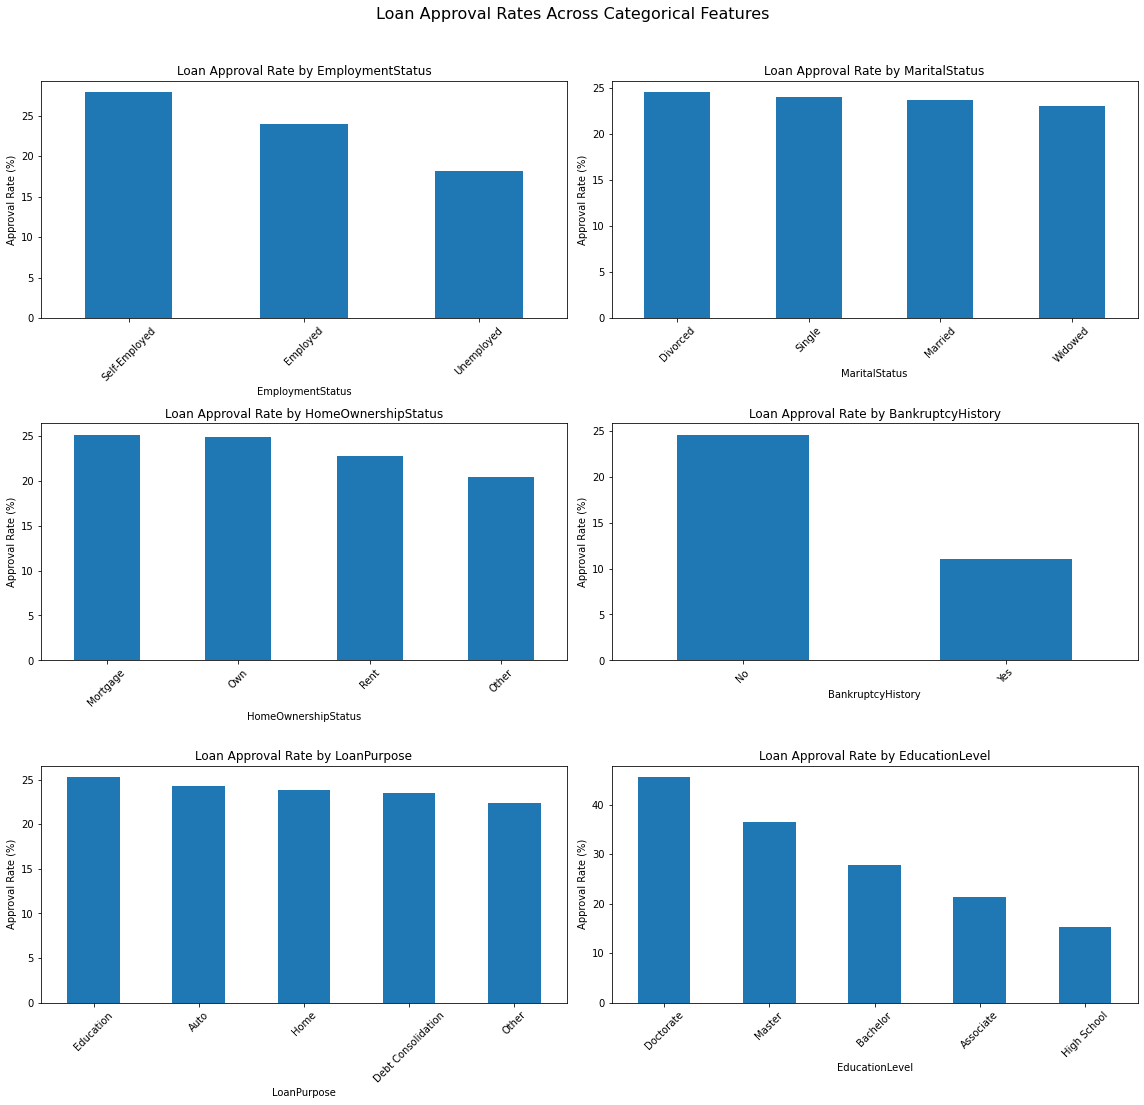

In [51]:
# Approval rate by categorical features

fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for ax, feature in zip(axes.flatten(), categorical_features):
    
    approval_rate = (
        df.groupby(feature)['LoanApproved']
        .mean()
        .sort_values(ascending=False)
        * 100
    )
    
    approval_rate.plot(
        kind='bar',
        ax=ax
    )
    
    ax.set_title(f'Loan Approval Rate by {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Approval Rate (%)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Loan Approval Rates Across Categorical Features',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

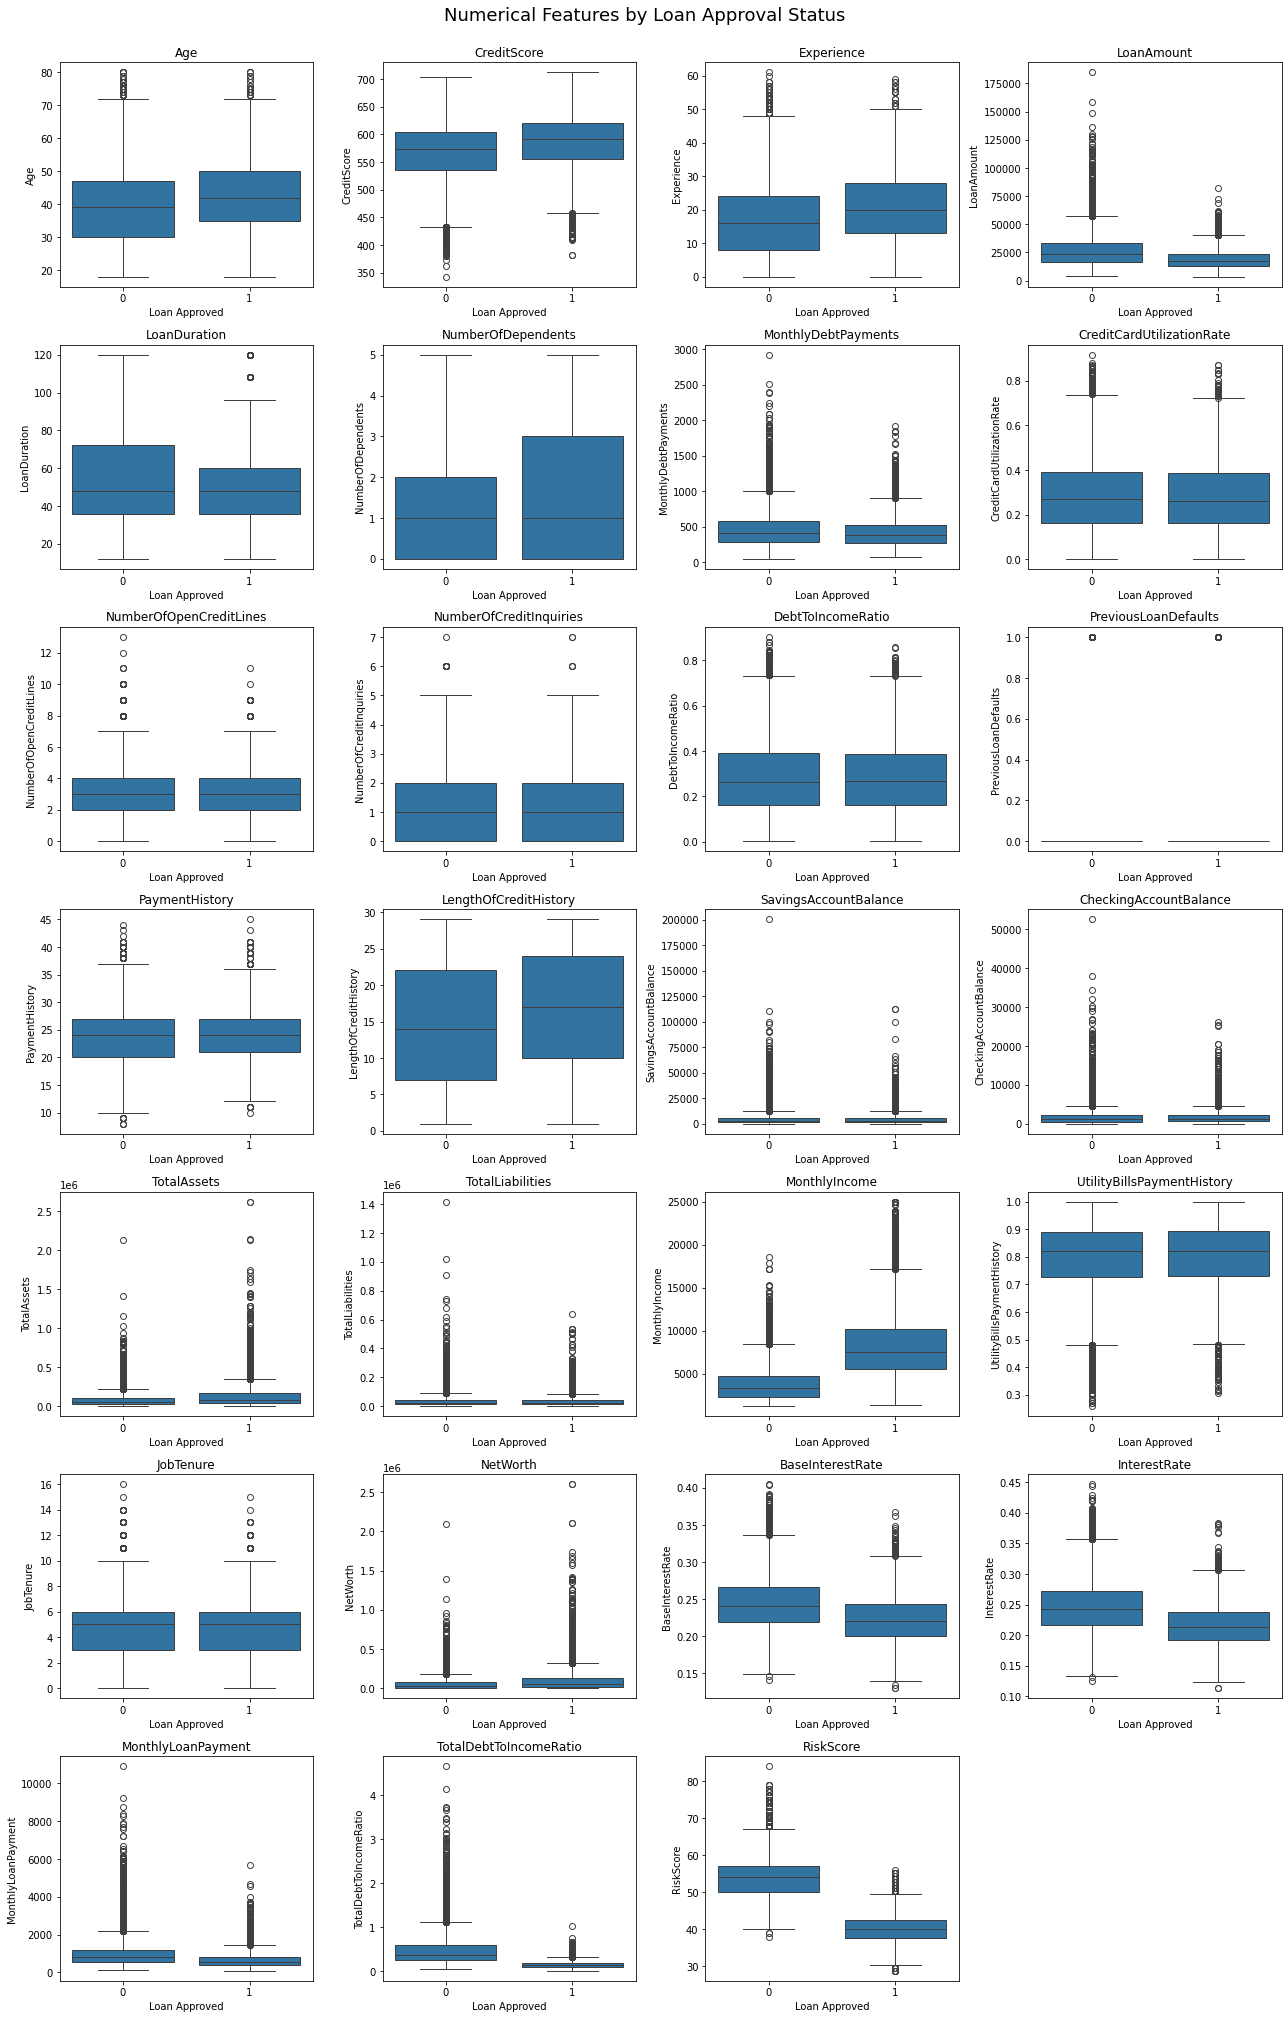

In [52]:
# All numerical features by loan approval status

fig, axes = plt.subplots(7, 4, figsize=(18, 28))

axes = axes.flatten()

for ax, feature in zip(axes, numerical_features):
    
    sns.boxplot(
        data=df,
        x='LoanApproved',
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature)
    ax.set_xlabel('Loan Approved')
    ax.set_ylabel(feature)

# Hide unused subplot
for ax in axes[len(numerical_features):]:
    ax.set_visible(False)

plt.suptitle(
    'Numerical Features by Loan Approval Status',
    fontsize=18,
    y=1.00
)

plt.tight_layout()
plt.show()

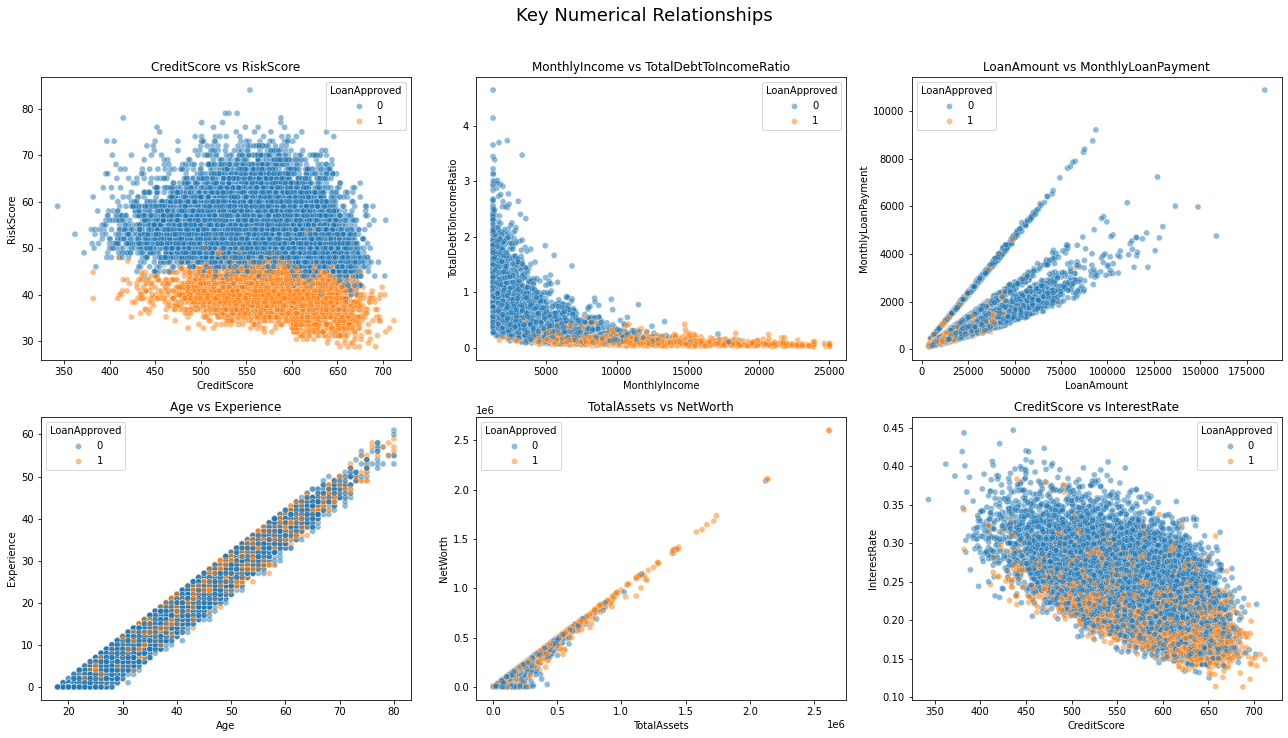

In [53]:
# Key numerical relationships

relationships = [
    ('CreditScore', 'RiskScore'),
    ('MonthlyIncome', 'TotalDebtToIncomeRatio'),
    ('LoanAmount', 'MonthlyLoanPayment'),
    ('Age', 'Experience'),
    ('TotalAssets', 'NetWorth'),
    ('CreditScore', 'InterestRate')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (x_feature, y_feature) in zip(axes.flatten(), relationships):
    
    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue='LoanApproved',
        alpha=0.5,
        ax=ax
    )
    
    ax.set_title(f'{x_feature} vs {y_feature}')
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)

plt.suptitle(
    'Key Numerical Relationships',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

In [54]:
from scipy.stats import ttest_ind

approved = df[df['LoanApproved'] == 1]['CreditScore']
not_approved = df[df['LoanApproved'] == 0]['CreditScore']

t_stat, p_value = ttest_ind(
    approved,
    not_approved,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 20.682430077079495
P-value: 1.080382633197888e-92


In [55]:
# Statistical tests for key numerical features

from scipy.stats import ttest_ind

statistical_features = [
    'CreditScore',
    'MonthlyIncome',
    'LoanAmount',
    'DebtToIncomeRatio',
    'TotalDebtToIncomeRatio',
    'RiskScore'
]

statistical_results = []

for feature in statistical_features:
    
    approved = df[df['LoanApproved'] == 1][feature].dropna()
    not_approved = df[df['LoanApproved'] == 0][feature].dropna()
    
    t_stat, p_value = ttest_ind(
        approved,
        not_approved,
        equal_var=False
    )
    
    statistical_results.append({
        'Feature': feature,
        'T-statistic': t_stat,
        'P-value': p_value
    })

statistical_results_df = pd.DataFrame(statistical_results)

display(statistical_results_df)

,Feature,T-statistic,P-value
0,CreditScore,20.682430,1.080383e-92
1,MonthlyIncome,76.458650,0.000000e+00
2,LoanAmount,-44.143602,0.000000e+00
3,DebtToIncomeRatio,0.004856,9.961253e-01
4,TotalDebtToIncomeRatio,-105.557507,0.000000e+00
5,RiskScore,-197.686180,0.000000e+00


In [56]:
# Identify potential outliers using the IQR method

outlier_results = []

for feature in numerical_features:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_results.append({
        'Feature': feature,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_percentage
    })

outlier_results_df = (
    pd.DataFrame(outlier_results)
    .sort_values('Outlier Percentage', ascending=False)
)

display(outlier_results_df)

,Feature,Outlier Count,Outlier Percentage
11,PreviousLoanDefaults,2001,10.005
21,NetWorth,1564,7.820
14,SavingsAccountBalance,1547,7.735
17,TotalLiabilities,1533,7.665
15,CheckingAccountBalance,1522,7.610
16,TotalAssets,1442,7.210
25,TotalDebtToIncomeRatio,1152,5.760
24,MonthlyLoanPayment,1089,5.445
18,MonthlyIncome,925,4.625
3,LoanAmount,746,3.730


> **Statistical test findings:** Independent two-sample t-tests were conducted for six key numerical features to compare approved and non-approved loan applications. `CreditScore`, `MonthlyIncome`, `LoanAmount`, `TotalDebtToIncomeRatio`, and `RiskScore` showed statistically significant differences between the two groups, with p-values below 0.05. In contrast, `DebtToIncomeRatio` had a p-value of 0.9961, indicating no statistically significant difference in its mean between the two groups. These results identify variables that may contain useful information for distinguishing approval outcomes, although statistical significance alone does not determine predictive importance or establish causation.


> **Feature engineering :** The exploratory analysis identified several opportunities for feature engineering and feature selection. `Age` and `Experience` have a very strong correlation of 0.983, while `TotalAssets` and `NetWorth` have a correlation of 0.979, indicating substantial overlap between these variables. `BaseInterestRate` and `InterestRate` are also strongly correlated at 0.835, while `LoanAmount` and `MonthlyLoanPayment` have a correlation of 0.781.
>
> The group of income and debt-related variables also provides opportunities to represent an applicant's repayment burden more effectively. During Data Preparation, these relationships will be considered when deciding whether transformations, derived features, feature selection, or regularization are appropriate. No features will be removed solely on the basis of correlation during the Data Understanding stage.


In [57]:
# Compare RiskScore by loan approval status

risk_score_summary = (
    df.groupby('LoanApproved')['RiskScore']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

display(risk_score_summary)

,count,mean,median,min,max
LoanApproved,,,,,
0,15220,54.106307,54.0,38.0,84.0
1,4780,40.133389,40.0,28.8,56.0


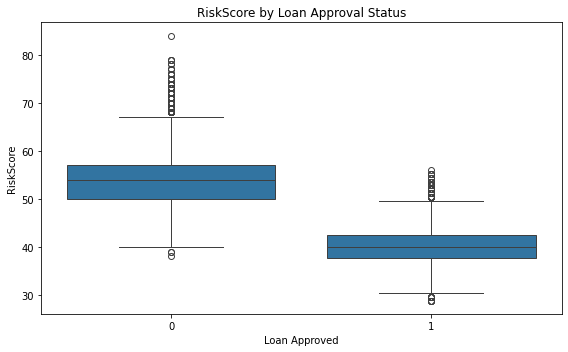

In [58]:
# RiskScore distribution by loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='LoanApproved',
    y='RiskScore'
)

plt.title('RiskScore by Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('RiskScore')

plt.tight_layout()
plt.show()

> **Potential data leakage:** `RiskScore` shows a substantial difference between approved and non-approved applications. The mean RiskScore is 54.11 for applications that were not approved and 40.13 for applications that were approved. The ranges also differ, with approved applications ranging from 28.8 to 56.0 and non-approved applications ranging from 38.0 to 84.0.
>
> This strong relationship suggests that `RiskScore` contains considerable information about the approval outcome. However, the relationship alone does not prove data leakage. Before using this variable in the predictive model, its definition and timing must be considered. If RiskScore was calculated using information that became available only after the loan decision, including it would cause data leakage and produce an unrealistically optimistic model. Therefore, RiskScore will be investigated further during Data Preparation and modeling before a final decision is made about its use.


## Data Understanding Summary

> The dataset contains 20,000 loan applications with 35 variables. The analysis identified missing values, class imbalance, potential outliers, strong correlations among some features, and differences in approval rates across several applicant characteristics. `AnnualIncome` requires conversion from text to numerical format, while `RiskScore` requires further investigation for possible data leakage. These findings will guide the data preparation and modeling stages.


# **4.0 Data Preparation**

## Preprocessing Strategy

> The preprocessing strategy will use separate pipelines for numerical, categorical, and ordinal features. A `ColumnTransformer` will combine these pipelines into one preprocessing workflow, while a `Pipeline` will connect preprocessing with the machine-learning models.
>
> Numerical features will be imputed using the median because financial variables can contain extreme values that may make the mean less representative. Numerical features will then be scaled for models that are sensitive to differences in feature magnitude, such as logistic regression.
>
> Categorical features will be imputed using the most frequent category and then encoded using one-hot encoding. This allows machine-learning models to work with non-numerical categories without assuming an artificial order between them.
>
> `EducationLevel` will be handled separately as an ordinal feature because its categories have a natural order. Ordinal encoding will preserve this ordering.
>
> `AnnualIncome` will first be converted from text into a numerical value because it represents income but is currently stored with dollar signs and commas.
>
> The target variable, `LoanApproved`, will not be included in the preprocessing transformations because it is the outcome we are trying to predict.


In [59]:
# Data Preparation Imports

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.linear_model import LogisticRegression

In [60]:
# Convert AnnualIncome from text to numerical format

df['AnnualIncome'] = (
    df['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Check the result
print(df['AnnualIncome'].dtype)
print(df['AnnualIncome'].head())

float64
0     39948.0
1     39709.0
2     40724.0
3     69084.0
4    103264.0
Name: AnnualIncome, dtype: float64


In [62]:
# Define target and predictor variables

target = 'LoanApproved'

features = [
    'Age',
    'AnnualIncome',
    'CreditScore',
    'EmploymentStatus',
    'EducationLevel',
    'Experience',
    'LoanAmount',
    'LoanDuration',
    'MaritalStatus',
    'NumberOfDependents',
    'HomeOwnershipStatus',
    'MonthlyDebtPayments',
    'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries',
    'DebtToIncomeRatio',
    'BankruptcyHistory',
    'LoanPurpose',
    'PreviousLoanDefaults',
    'PaymentHistory',
    'LengthOfCreditHistory',
    'SavingsAccountBalance',
    'CheckingAccountBalance',
    'TotalAssets',
    'TotalLiabilities',
    'MonthlyIncome',
    'UtilityBillsPaymentHistory',
    'JobTenure',
    'NetWorth',
    'BaseInterestRate',
    'InterestRate',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio'
]

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20000, 33)
Target shape: (20000,)


In [63]:
# Numerical features

numerical_features = [
    'Age',
    'AnnualIncome',
    'CreditScore',
    'Experience',
    'LoanAmount',
    'LoanDuration',
    'NumberOfDependents',
    'MonthlyDebtPayments',
    'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries',
    'DebtToIncomeRatio',
    'PreviousLoanDefaults',
    'PaymentHistory',
    'LengthOfCreditHistory',
    'SavingsAccountBalance',
    'CheckingAccountBalance',
    'TotalAssets',
    'TotalLiabilities',
    'MonthlyIncome',
    'UtilityBillsPaymentHistory',
    'JobTenure',
    'NetWorth',
    'BaseInterestRate',
    'InterestRate',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio'
]

# Categorical features

categorical_features = [
    'EmploymentStatus',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'BankruptcyHistory',
    'LoanPurpose'
]

# Ordinal feature

ordinal_features = ['EducationLevel']

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Ordinal features:", len(ordinal_features))

Numerical features: 27
Categorical features: 5
Ordinal features: 1


In [64]:
# Check EducationLevel categories

print(df['EducationLevel'].value_counts(dropna=False))

Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: EducationLevel, dtype: int64


In [65]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (16000, 33)
Testing set: (4000, 33)

Training target distribution:
0    0.761
1    0.239
Name: LoanApproved, dtype: float64

Testing target distribution:
0    0.761
1    0.239
Name: LoanApproved, dtype: float64


In [66]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [69]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse=False
    ))
])

In [71]:
# Ordinal preprocessing pipeline

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[[
            'High School',
            'Associate',
            'Bachelor',
            'Master',
            'Doctorate'
        ]]
    ))
])

In [72]:
# Combine numerical, categorical, and ordinal preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ],
    remainder='drop'
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [73]:
# Fit preprocessing using training data only

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (16000, 46)
Processed testing shape: (4000, 46)


In [74]:
# Check for missing values after preprocessing

print(
    "Missing values in processed training data:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed testing data:",
    np.isnan(X_test_processed).sum()
)

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [75]:
# Compare feature counts before and after preprocessing

print("Original feature count:", X_train.shape[1])
print("Processed feature count:", X_train_processed.shape[1])

Original feature count: 33
Processed feature count: 46


In [77]:
# Check the processed data

print("Original feature count:", X_train.shape[1])
print("Processed feature count:", X_train_processed.shape[1])

print("\nFirst 5 processed rows:")
print(X_train_processed[:5])

Original feature count: 33
Processed feature count: 46

First 5 processed rows:
[[ 8.81181262e-01 -6.17962119e-01 -1.32466997e+00  8.36973890e-01
  -6.35936699e-01 -7.32875070e-01  1.07025067e+00 -1.01764029e+00
   3.50518601e-01  5.62348825e-01  1.05484046e-02  9.09354902e-01
  -3.34027345e-01 -2.04449005e-01  3.68756961e-01 -1.98603878e-01
  -5.27446426e-01 -2.09295155e-01 -3.98971353e-01 -6.19368884e-01
  -2.17276466e-01  4.39617225e-01 -1.49970711e-01  2.88777778e-01
   4.46824491e-01 -3.78645323e-01 -2.92140959e-01  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-6.27212493e-02 -1.92508528e-01  7.91834956e-01 -2.21426097e-01
   1.77408020e-03  1.21788206e+00 -1.09078046e+00  7.15028451e-01
  -2.51721936e-01 -5.877222

In [78]:
# Final preprocessing checks

print("Training rows:", X_train_processed.shape[0])
print("Testing rows:", X_test_processed.shape[0])
print("Processed features:", X_train_processed.shape[1])
print("Missing values:", np.isnan(X_train_processed).sum())

print("\nData preparation completed successfully.")

Training rows: 16000
Testing rows: 4000
Processed features: 46
Missing values: 0

Data preparation completed successfully.


In [ ]:
# Check the processed data

print("Original feature count:", X_train.shape[1])
print("Processed feature count:", X_train_processed.shape[1])

print("\nFirst 5 processed rows:")
print(X_train_processed[:5])

Original feature count: 33
Processed feature count: 46

First 5 processed rows:
[[ 8.81181262e-01 -6.17962119e-01 -1.32466997e+00  8.36973890e-01
  -6.35936699e-01 -7.32875070e-01  1.07025067e+00 -1.01764029e+00
   3.50518601e-01  5.62348825e-01  1.05484046e-02  9.09354902e-01
  -3.34027345e-01 -2.04449005e-01  3.68756961e-01 -1.98603878e-01
  -5.27446426e-01 -2.09295155e-01 -3.98971353e-01 -6.19368884e-01
  -2.17276466e-01  4.39617225e-01 -1.49970711e-01  2.88777778e-01
   4.46824491e-01 -3.78645323e-01 -2.92140959e-01  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-6.27212493e-02 -1.92508528e-01  7.91834956e-01 -2.21426097e-01
   1.77408020e-03  1.21788206e+00 -1.09078046e+00  7.15028451e-01
  -2.51721936e-01 -5.877222

###  Data Preparation summary

**Preprocessing Strategy**

> A separate preprocessing pipeline was created for numerical, categorical, and ordinal variables. Numerical features were processed using median imputation and standardization. Categorical features were processed using most-frequent imputation followed by one-hot encoding. `EducationLevel` was treated as an ordinal variable and encoded according to its natural educational order.
>
> `AnnualIncome` was converted from text into a numerical format before modeling. `RiskScore` was excluded from the predictors at this stage because its relationship with the target requires further investigation for possible data leakage.
>
> The preprocessing steps were combined using `ColumnTransformer`, ensuring that each feature type receives the appropriate treatment. The resulting preprocessing structure can be integrated into machine learning pipelines so that the same transformations are consistently applied during training and testing.

**Preprocessing Validation**

> The preprocessing process successfully transformed the 33 original predictor variables into 46 processed features. The training dataset contains 16,000 observations and the testing dataset contains 4,000 observations.
>
> No missing values remain in either the processed training or testing data. This confirms that the imputation procedures worked as intended. The numerical variables have also been standardized, while categorical variables have been converted into machine-readable numerical representations.
>
> The preprocessing stage is therefore ready for use in model development.


# **5.0 Modeling**

## Modeling Approach

> The problem is treated as a binary classification task because the objective is to predict whether a loan application will be approved or not approved. The target variable is `LoanApproved`, where 0 represents a non-approved application and 1 represents an approved application.
>
> Five different classification algorithms are evaluated to compare models with different strengths: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors.
>
> Each model is placed inside a complete machine learning pipeline containing the preprocessing steps developed during Data Preparation. This ensures that preprocessing is performed consistently and prevents information from the test dataset from influencing model training.


In [79]:
# Modeling imports

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
# Define the models

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),

    'K-Nearest Neighbors': KNeighborsClassifier(
        n_jobs=-1
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- K-Nearest Neighbors


In [81]:
# Create a complete pipeline for each model

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Complete pipelines created successfully.")

Complete pipelines created successfully.


In [82]:
# Cross-validation settings

cv_folds = 5

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("Cross-validation folds:", cv_folds)
print("Evaluation metrics:", list(scoring_metrics.keys()))

Cross-validation folds: 5
Evaluation metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


In [83]:
# Run 5-fold cross-validation for all models

cv_results = []

for name, pipeline in model_pipelines.items():
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_folds,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.956250,0.865526,0.967310,0.913569,0.994550
1,Gradient Boosting,0.941250,0.904763,0.843092,0.872769,0.985228
2,Random Forest,0.925750,0.892883,0.783471,0.834563,0.976949
3,K-Nearest Neighbors,0.884250,0.833142,0.645131,0.726969,0.918043
4,Decision Tree,0.888875,0.774336,0.754966,0.764505,0.842948


<Figure size 864x432 with 0 Axes>

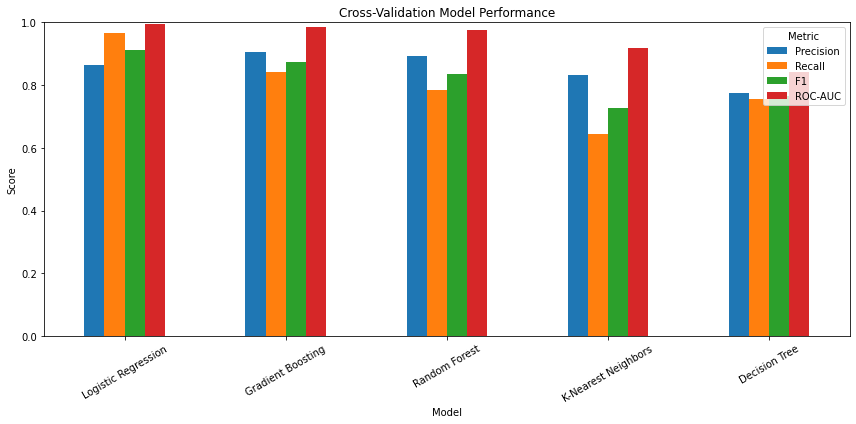

In [84]:
# Compare model performance

plt.figure(figsize=(12, 6))

metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC']

cv_results_plot = cv_results_df.set_index('Model')[metrics_to_plot]

cv_results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Cross-Validation Model Performance')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [85]:
# Define parameter grids for model tuning

param_grids = {

    'Logistic Regression': {
        'model__C': [0.1, 1, 10],
        'model__solver': ['liblinear']
    },

    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 10, 20],
        'model__min_samples_leaf': [1, 5, 10]
    },

    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 10],
        'model__min_samples_leaf': [1, 5]
    },

    'Gradient Boosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    },

    'K-Nearest Neighbors': {
        'model__n_neighbors': [5, 10, 20],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    }
}

print("Parameter grids created successfully.")

Parameter grids created successfully.


In [86]:
# Count parameter combinations

from itertools import product

for model_name, grid in param_grids.items():
    combinations = 1
    
    for values in grid.values():
        combinations *= len(values)
    
    print(f"{model_name}: {combinations} combinations")

Logistic Regression: 3 combinations
Decision Tree: 36 combinations
Random Forest: 24 combinations
Gradient Boosting: 8 combinations
K-Nearest Neighbors: 12 combinations


In [87]:
# Tune each model using GridSearchCV

grid_search_results = []
best_models = {}

for name in model_pipelines:
    
    print(f"\nTuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=model_pipelines[name],
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search
    
    grid_search_results.append({
        'Model': name,
        'Best ROC-AUC': grid_search.best_score_,
        'Best Parameters': grid_search.best_params_
    })
    
    print("Best ROC-AUC:", grid_search.best_score_)
    print("Best Parameters:", grid_search.best_params_)


Tuning Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    3.9s finished


Best ROC-AUC: 0.9945933705587267
Best Parameters: {'model__C': 10, 'model__solver': 'liblinear'}

Tuning Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 180 out of 180 | elapsed:   45.4s finished


Best ROC-AUC: 0.9411101687503074
Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


...

Best ROC-AUC: 0.9776809208571805
Best Parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:  4.1min finished


Best ROC-AUC: 0.9900770975622379
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Tuning K-Nearest Neighbors...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  2.4min finished


Best ROC-AUC: 0.9666244630308694
Best Parameters: {'model__n_neighbors': 20, 'model__p': 1, 'model__weights': 'distance'}


In [88]:
# Display tuning results

tuning_results_df = pd.DataFrame(grid_search_results)

tuning_results_df = tuning_results_df.sort_values(
    by='Best ROC-AUC',
    ascending=False
).reset_index(drop=True)

tuning_results_df

,Model,Best ROC-AUC,Best Parameters
0,Logistic Regression,0.994593,"{'model__C': 10, 'model__solver': 'liblinear'}"
1,Gradient Boosting,0.990077,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,Random Forest,0.977681,"{'model__max_depth': 20, 'model__min_samples_l..."
3,K-Nearest Neighbors,0.966624,"{'model__n_neighbors': 20, 'model__p': 1, 'mod..."
4,Decision Tree,0.941110,"{'model__max_depth': 5, 'model__min_samples_le..."


In [89]:
# Identify the model with the highest cross-validation ROC-AUC

best_model_name = tuning_results_df.iloc[0]['Model']

best_grid_search = best_models[best_model_name]

best_model = best_grid_search.best_estimator_

print("Best tuned model:", best_model_name)
print("Best cross-validation ROC-AUC:", best_grid_search.best_score_)
print("Best parameters:")
print(best_grid_search.best_params_)

Best tuned model: Logistic Regression
Best cross-validation ROC-AUC: 0.9945933705587267
Best parameters:
{'model__C': 10, 'model__solver': 'liblinear'}


In [92]:
# Show all parameter combinations tested for each model

for name, grid_search in best_models.items():
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    results = pd.DataFrame(grid_search.cv_results_)
    
    results = results[
        ['mean_test_score', 'std_test_score', 'params']
    ].sort_values(
        by='mean_test_score',
        ascending=False
    )
    
    print(results.head(5))


Logistic Regression
   mean_test_score  std_test_score  \
2         0.994593        0.000504   
1         0.994526        0.000591   
0         0.993392        0.000895   

                                            params  
2   {'model__C': 10, 'model__solver': 'liblinear'}  
1    {'model__C': 1, 'model__solver': 'liblinear'}  
0  {'model__C': 0.1, 'model__solver': 'liblinear'}  

Decision Tree
    mean_test_score  std_test_score  \
16         0.941110        0.003219   
15         0.941110        0.003219   
17         0.941110        0.003219   
12         0.940992        0.003897   
14         0.940992        0.003897   

                                               params  
16  {'model__max_depth': 5, 'model__min_samples_le...  
15  {'model__max_depth': 5, 'model__min_samples_le...  
17  {'model__max_depth': 5, 'model__min_samples_le...  
12  {'model__max_depth': 5, 'model__min_samples_le...  
14  {'model__max_depth': 5, 'model__min_samples_le...  

Random Forest
    mean_test

In [93]:
# Compare initial and tuned ROC-AUC scores

comparison = cv_results_df[['Model', 'ROC-AUC']].copy()

comparison = comparison.rename(
    columns={'ROC-AUC': 'Initial ROC-AUC'}
)

tuned_scores = tuning_results_df[['Model', 'Best ROC-AUC']]

comparison = comparison.merge(
    tuned_scores,
    on='Model'
)

comparison['Improvement'] = (
    comparison['Best ROC-AUC'] -
    comparison['Initial ROC-AUC']
)

comparison = comparison.sort_values(
    by='Best ROC-AUC',
    ascending=False
).reset_index(drop=True)

comparison

,Model,Initial ROC-AUC,Best ROC-AUC,Improvement
0,Logistic Regression,0.994550,0.994593,0.000043
1,Gradient Boosting,0.985228,0.990077,0.004849
2,Random Forest,0.976949,0.977681,0.000732
3,K-Nearest Neighbors,0.918043,0.966624,0.048581
4,Decision Tree,0.842948,0.941110,0.098162


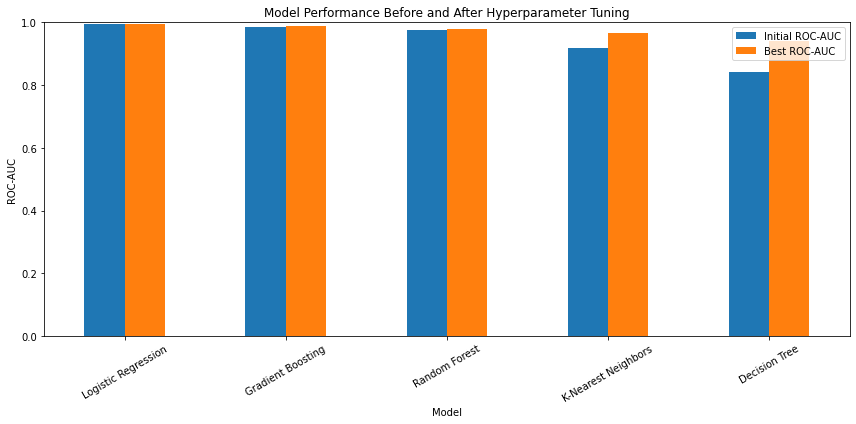

In [94]:
# Visualize model performance before and after tuning

comparison_plot = comparison.set_index('Model')[
    ['Initial ROC-AUC', 'Best ROC-AUC']
]

comparison_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Before and After Hyperparameter Tuning')
plt.ylabel('ROC-AUC')
plt.xlabel('Model')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
# Final modeling and optimization summary

print("MODEL OPTIMIZATION COMPLETED")
print("-" * 50)

print("Selected model based on cross-validation:")
print(best_model_name)

print("\nBest cross-validation ROC-AUC:")
print(round(best_grid_search.best_score_, 4))

print("\nBest parameters:")
for parameter, value in best_grid_search.best_params_.items():
    print(f"{parameter}: {value}")

MODEL OPTIMIZATION COMPLETED
--------------------------------------------------
Selected model based on cross-validation:
Logistic Regression

Best cross-validation ROC-AUC:
0.9946

Best parameters:
model__C: 10
model__solver: liblinear


## Modeling Summary

> Five classification algorithms were developed to predict `LoanApproved`: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors. Each model was implemented within a complete pipeline containing the preprocessing steps developed during Data Preparation. This ensured that numerical, categorical, and ordinal variables were processed consistently during model training.
>
> A stratified 80/20 train-test split was used, with 5-fold cross-validation applied to the training data. Model performance was compared using accuracy, precision, recall, F1 score, and ROC-AUC. ROC-AUC was used as the primary comparison metric because the target variable is imbalanced and the model needs to distinguish effectively between approved and non-approved applications.
>
> Logistic Regression achieved the highest initial cross-validation ROC-AUC of **0.9946**, followed by Gradient Boosting at **0.9852**, Random Forest at **0.9769**, K-Nearest Neighbors at **0.9180**, and Decision Tree at **0.8429**.
>
> Hyperparameter optimization was then performed using GridSearchCV with 5-fold cross-validation. The best Logistic Regression configuration used `C=10` and the `liblinear` solver, achieving a cross-validation ROC-AUC of **0.9946**. Gradient Boosting achieved **0.9901**, Random Forest **0.9777**, K-Nearest Neighbors **0.9666**, and Decision Tree **0.9411** after tuning.
>
> Based on the cross-validation results, the Logistic Regression configuration with `C=10` and `solver='liblinear'` was selected for the next stage of the project. Final performance on the unseen test data will be assessed separately during the Evaluation


## **6.0 Final Model Evaluation and conclusion**

> The final evaluation uses the unseen test dataset that was kept separate from model training and hyperparameter tuning. This provides a more realistic estimate of how the trained models are expected to perform on new loan applications.
>
> The evaluation uses accuracy, precision, recall, F1 score, and ROC-AUC. These metrics provide different perspectives on model performance and are particularly important because the dataset contains more non-approved than approved applications.


In [96]:
test_results = []

for name, grid_search in best_models.items():
    model = grid_search.best_estimator_
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

test_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.96075,0.877956,0.970711,0.922007,0.994484
1,Gradient Boosting,0.95750,0.924406,0.895397,0.909671,0.991257
2,Random Forest,0.93125,0.897316,0.804393,0.848318,0.979484
3,K-Nearest Neighbors,0.90675,0.913475,0.673640,0.775436,0.966876
4,Decision Tree,0.87775,0.687852,0.894351,0.777626,0.947132


In [116]:
final_model_name = 'Logistic Regression'

final_model = best_models[final_model_name].best_estimator_

print("Final model selected from cross-validation:", final_model_name)
print("Best parameters:", best_models[final_model_name].best_params_)

Final model selected from cross-validation: Logistic Regression
Best parameters: {'model__C': 10, 'model__solver': 'liblinear'}


In [98]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [99]:
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=['Metric', 'Score']
)

final_metrics_df

,Metric,Score
0,Accuracy,0.960750
1,Precision,0.877956
2,Recall,0.970711
3,F1 Score,0.922007
4,ROC-AUC,0.994484


In [100]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Approved', 'Approved']
))

              precision    recall  f1-score   support

Not Approved       0.99      0.96      0.97      3044
    Approved       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



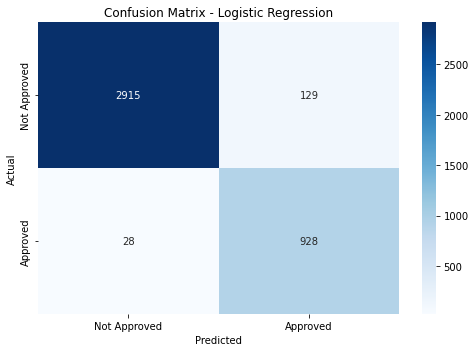

In [101]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved']
)

plt.title(f'Confusion Matrix - {final_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [102]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 2915
False Positives: 129
False Negatives: 28
True Positives: 928


In [103]:
false_approval_cost = 50000
false_denial_cost = 8000

false_approval_impact = fp * false_approval_cost
false_denial_impact = fn * false_denial_cost

total_error_impact = false_approval_impact + false_denial_impact

print(f"False approval impact: ${false_approval_impact:,.2f}")
print(f"False denial impact: ${false_denial_impact:,.2f}")
print(f"Total estimated error impact: ${total_error_impact:,.2f}")

False approval impact: $6,450,000.00
False denial impact: $224,000.00
Total estimated error impact: $6,674,000.00


In [104]:
business_impact = pd.DataFrame({
    'Error Type': [
        'False Approval',
        'False Denial'
    ],
    'Count': [
        fp,
        fn
    ],
    'Cost Per Error': [
        false_approval_cost,
        false_denial_cost
    ],
    'Estimated Impact': [
        false_approval_impact,
        false_denial_impact
    ]
})

business_impact

,Error Type,Count,Cost Per Error,Estimated Impact
0,False Approval,129,50000,6450000
1,False Denial,28,8000,224000


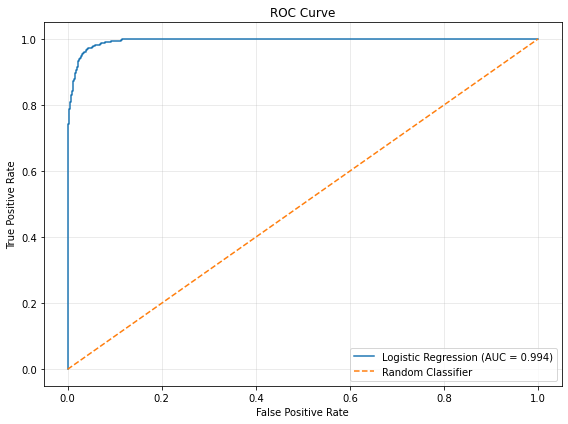

In [105]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'{final_model_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

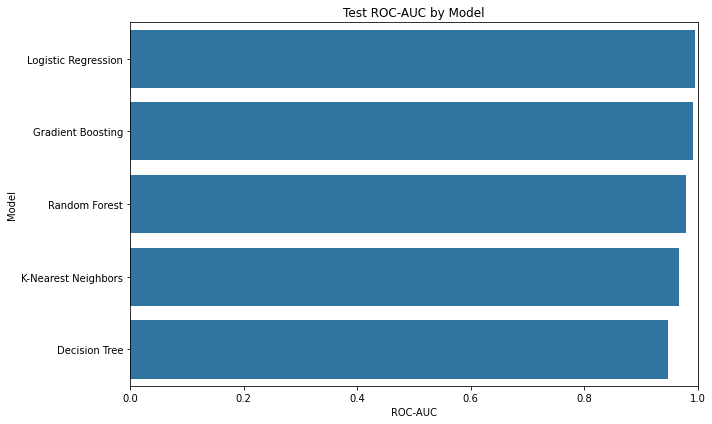

In [106]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=test_results_df,
    x='ROC-AUC',
    y='Model'
)

plt.title('Test ROC-AUC by Model')
plt.xlabel('ROC-AUC')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [107]:
test_analysis = X_test.copy()

test_analysis['Actual'] = y_test.values
test_analysis['Predicted'] = y_pred
test_analysis['Probability'] = y_prob

test_analysis.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,Actual,Predicted,Probability
10665,39,22074.0,609,Employed,Associate,17,60015,48,Married,0,...,0.588898,7,4186,0.250515,0.237359,1947.847130,1.376922,0,0,1.143221e-27
7602,45,95060.0,563,Employed,High School,24,5499,96,Married,0,...,0.949065,7,6385,0.258999,0.265134,138.490989,0.060024,0,1,6.548140e-01
11808,52,209874.0,573,Employed,Bachelor,33,21138,36,Married,1,...,0.848766,2,10898,0.219638,0.232880,821.421927,0.053428,1,1,1.000000e+00
222,48,35187.0,574,Employed,Bachelor,24,82538,48,Married,1,...,0.715871,4,11091,0.290538,0.288652,2917.633022,1.190087,0,0,4.988446e-26
17081,38,36128.0,608,Employed,Doctorate,12,22890,48,Married,3,...,0.922217,3,8634,0.213890,0.214407,714.241142,0.585665,0,0,7.893386e-07


In [109]:
employment_performance = (
    test_analysis
    .groupby('EmploymentStatus')
    .apply(
        lambda group: pd.Series({
            'Count': len(group),
            'Accuracy': accuracy_score(
                group['Actual'],
                group['Predicted']
            ),
            'Precision': precision_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            ),
            'Recall': recall_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            )
        })
    )
    .reset_index()
)

employment_performance

,EmploymentStatus,Count,Accuracy,Precision,Recall
0,Employed,3402.0,0.961199,0.881057,0.970874
1,Self-Employed,311.0,0.951768,0.852632,0.987805
2,Unemployed,287.0,0.965157,0.870370,0.940000


In [111]:
education_performance = (
    test_analysis
    .groupby('EducationLevel')
    .apply(
        lambda group: pd.Series({
            'Count': len(group),
            'Accuracy': accuracy_score(
                group['Actual'],
                group['Predicted']
            ),
            'Precision': precision_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            ),
            'Recall': recall_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            )
        })
    )
    .reset_index()
)

education_performance

,EducationLevel,Count,Accuracy,Precision,Recall
0,Associate,782.0,0.962916,0.867403,0.969136
1,Bachelor,1163.0,0.959587,0.894886,0.969231
2,Doctorate,156.0,0.929487,0.871795,0.985507
3,High School,1086.0,0.976059,0.888889,0.963855
4,Master,620.0,0.950000,0.901186,0.974359


In [113]:
homeownership_performance = (
    test_analysis
    .groupby('HomeOwnershipStatus')
    .apply(
        lambda group: pd.Series({
            'Count': len(group),
            'Accuracy': accuracy_score(
                group['Actual'],
                group['Predicted']
            ),
            'Precision': precision_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            ),
            'Recall': recall_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            )
        })
    )
    .reset_index()
)

homeownership_performance

,HomeOwnershipStatus,Count,Accuracy,Precision,Recall
0,Mortgage,1624.0,0.955665,0.870824,0.965432
1,Other,415.0,0.942169,0.755319,0.986111
2,Own,786.0,0.964377,0.920561,0.947115
3,Rent,1175.0,0.971915,0.896667,0.992620


In [114]:
loanpurpose_performance = (
    test_analysis
    .groupby('LoanPurpose')
    .apply(
        lambda group: pd.Series({
            'Count': len(group),
            'Accuracy': accuracy_score(
                group['Actual'],
                group['Predicted']
            ),
            'Precision': precision_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            ),
            'Recall': recall_score(
                group['Actual'],
                group['Predicted'],
                zero_division=0
            )
        })
    )
    .reset_index()
)

loanpurpose_performance

,LoanPurpose,Count,Accuracy,Precision,Recall
0,Auto,773.0,0.968952,0.910000,0.968085
1,Debt Consolidation,1030.0,0.955340,0.850000,0.969298
2,Education,590.0,0.950847,0.858824,0.966887
3,Home,1196.0,0.965719,0.896024,0.976667
4,Other,411.0,0.958637,0.860000,0.966292


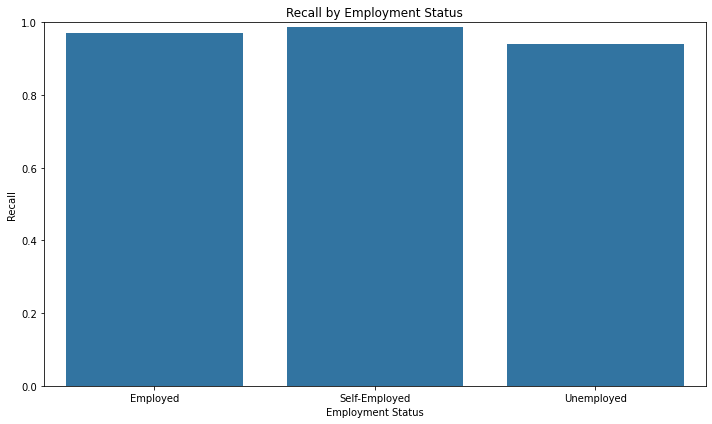

In [115]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=employment_performance,
    x='EmploymentStatus',
    y='Recall'
)

plt.title('Recall by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#  Feature Importance and Significance

##  Feature Importance

> Understanding which variables contribute most strongly to the model's predictions helps make the model more interpretable. For the Logistic Regression model, the coefficients indicate the direction and relative strength of the relationship between each processed feature and the predicted loan approval outcome.
>
> Because numerical variables were standardized during preprocessing, their coefficients can be compared more meaningfully. Categorical variables were one-hot encoded, meaning each coefficient represents the contribution of a particular category.
>
> Positive coefficients are associated with higher predicted approval probabilities, while negative coefficients are associated with lower predicted approval probabilities. These relationships represent patterns learned by the model and should not be interpreted as proof of causation.
>
> The feature-importance results can also help FinTech Innovations identify variables that require additional monitoring for data quality, fairness, business relevance, or potential data leakage.

##  Business Recommendations

> The model can be used as a decision-support tool to provide a consistent initial assessment of loan applications and reduce the workload associated with manual review.
>
> Applications with uncertain predictions can be referred to human reviewers rather than being automatically approved or denied.
>
> The test-set results produced 129 false approvals and 28 false denials. Based on the assumed costs provided in the business scenario, these correspond to estimated impacts of $6.45 million and $224,000 respectively on the 4,000-application test set. This demonstrates why the organization should consider the financial consequences of different prediction errors when determining the appropriate classification threshold.
>
> The variables with the strongest model coefficients should be monitored for changes in their distributions, data quality, and relationship with loan approval outcomes. Model performance should also continue to be reviewed across relevant applicant segments after deployment.

#  Final Deliverable

##  Executive Summary

> FinTech Innovations currently faces a loan-review process that can be slow and inconsistent when applications are assessed manually. This project developed a machine learning classification approach to predict whether a loan application is likely to be approved.
>
> The analysis used 20,000 historical loan applications containing applicant, financial, credit, and loan information. Exploratory analysis identified missing values, class imbalance, potential outliers, strong relationships among several numerical variables, and differences in approval rates across applicant characteristics.
>
> A structured preprocessing pipeline was developed using `ColumnTransformer` and `Pipeline`. Numerical variables were processed using median imputation and standardization, categorical variables were imputed and one-hot encoded, and `EducationLevel` was encoded according to its natural order. `AnnualIncome` was converted from text into numerical format.
>
> Five classification algorithms were compared using five-fold cross-validation: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors. GridSearchCV was then used to optimize the model hyperparameters.
>
> Logistic Regression was selected through cross-validation using `C=10` and the `liblinear` solver. On the unseen test dataset, the model achieved 96.08% accuracy, 87.80% precision, 97.07% recall, 92.20% F1 score, and a ROC-AUC of 99.45%.
>
> The confusion matrix showed 129 false approvals and 28 false denials on the 4,000-application test set. Using the assumed error costs, these correspond to an estimated error impact of $6.674 million on the test set. This highlights the importance of considering the financial consequences of different prediction errors rather than relying on accuracy alone.
>
> Segment analysis was conducted across employment status, education level, home ownership status, and loan purpose. The model showed some differences in performance across segments, which should be monitored over time and interpreted alongside the number of observations in each group.
>
> Overall, the project demonstrates how machine learning can provide a consistent, data-driven approach to supporting loan-approval decisions while highlighting the need for human oversight, business-cost analysis, fairness monitoring, and ongoing model evaluation.

##  Recommendations for Implementation

> **1. Use the model as a decision-support tool.** The model can provide an initial prediction and approval probability for each new loan application.
>
> **2. Establish a manual-review process.** Applications with uncertain predictions should be directed to human reviewers rather than relying entirely on automated decisions.
>
> **3. Consider business costs when setting the classification threshold.** The organization should investigate alternative probability thresholds using the different financial costs of false approvals and false denials.
>
> **4. Monitor model performance.** Accuracy, precision, recall, F1 score, ROC-AUC, false approvals, and false denials should be monitored after deployment.
>
> **5. Monitor performance across applicant segments.** Segment-level performance should be reviewed periodically to identify meaningful changes in model behavior.
>
> **6. Maintain data-quality controls.** New applications should pass through the same preprocessing procedures used during model development to ensure consistency between training data and production data.

##  Potential Improvements

> Future versions of the project could include additional feature engineering using income, debt, assets, liabilities, and loan characteristics to create more meaningful financial ratios.
>
> Highly correlated variables such as `Age` and `Experience`, and `TotalAssets` and `NetWorth`, could be investigated further to determine whether feature selection or regularization can simplify the model while maintaining performance.
>
> The definition and timing of `RiskScore` should also be confirmed. If it is calculated using information that becomes available after the loan decision, it should remain excluded from the predictive model to prevent data leakage.
>
> Different probability thresholds should be tested using the financial costs of false approvals and false denials. This could provide a stronger connection between model predictions and the organization's risk objectives.
>
> Future work should also include more comprehensive fairness analysis across relevant applicant groups and continuous monitoring after deployment to identify changes in data distributions, model performance, and applicant behavior.

## Final Conclusion

> This project developed a complete machine learning workflow for supporting loan-approval decisions at FinTech Innovations. The workflow followed the CRISP-DM process from business understanding and exploratory analysis through data preparation, model development, hyperparameter optimization, and final evaluation.
>
> Five classification algorithms were evaluated using cross-validation, followed by hyperparameter optimization using GridSearchCV. Logistic Regression was selected through cross-validation and achieved strong performance on the previously unseen test dataset, with a ROC-AUC of 99.45% and recall of 97.07%.
>
> The evaluation also examined the model's confusion matrix, estimated financial impact of prediction errors, performance across applicant segments, and the features contributing to model predictions.
>
> The results provide a foundation for using machine learning as part of a more consistent and data-driven loan-review process. Before production implementation, additional validation should be completed, particularly around probability-threshold selection, fairness monitoring, data-leakage checks, human oversight, and ongoing model performance monitoring.